In [ ]:
import osmnx as ox
import random

In [ ]:
!pip3 install osmnx

In [ ]:
# Get street network for an area
G = ox.graph_from_place('Moscow')

# Get intersections
intersections = ox.graph_to_gdfs(G, nodes=True, edges=False)

# Get streets
streets = ox.graph_to_gdfs(G, nodes=False, edges=True)

In [ ]:
len(intersections)

In [ ]:
len(streets)

In [ ]:
intersections[0:3]

In [ ]:
streets[0:3]

In [ ]:
vertices_full = intersections.reset_index()

In [ ]:
# for index, row in vertices_full.iterrows():
#     print(row)

In [ ]:
edges_full = streets.reset_index()

In [ ]:
edges_full

In [ ]:
edges_full[(edges_full["lanes"] == "4")]

edges_full[(edges_full["u"] == 90058438)]
edges_full[(edges_full["v"] == 90058438)]

edges_full[edges_full["length"] < 1]

edges_full.isna().sum()

In [ ]:
import matplotlib as plt

In [392]:
! pip3 install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [398]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [ ]:
osmid_to_xy = {}

for index, row in vertices_full.iterrows():
    osmid_to_xy[row.osmid] = [row.x, row.y]


In [ ]:
cur_vertices = vertices_full[(37.6 <= vertices_full["x"]) & (vertices_full["x"] <= 37.8) & (55.6 <= vertices_full["y"]) & (vertices_full["y"] <= 55.8)]

plt.figure(figsize=(10, 10))

plt.scatter(cur_vertices["x"], cur_vertices["y"], s=0.5)



cur_v_set = set(cur_vertices["osmid"])


for index, row in edges_full.iterrows():
    if (row.u in cur_v_set) and (row.v in cur_v_set):
        [x1, y1] = osmid_to_xy[row.u]
        [x2, y2] = osmid_to_xy[row.v]
        plt.plot([x1, x2], [y1, y2], c="orange")

In [ ]:
cur_vertices = vertices_full[(37.4 <= vertices_full["x"]) & (vertices_full["x"] <= 37.725) & (55.6 <= vertices_full["y"]) & (vertices_full["y"] <= 55.87)]

plt.figure(figsize=(10, 10))

plt.scatter(cur_vertices["x"], cur_vertices["y"], s=1)

plt.show()

cur_v_set = set(cur_vertices["osmid"])

edge_count = 0

cur_edges = []

cur_edges_uv = []

for index, row in edges_full.iterrows():
    if (row.u in cur_v_set) and (row.v in cur_v_set):
        edge_count += 1
        if (edge_count % 100 == 0):
            print(edge_count)
        [x1, y1] = osmid_to_xy[row.u]
        [x2, y2] = osmid_to_xy[row.v]
        cur_edges.append([x1, x2, y1, y2])
        cur_edges_uv.append([row.u, row.v, row.length])
        
        # plt.plot([x1, x2], [y1, y2], c="orange")


In [ ]:
#cur_vertices = vertices_full[(37.65 <= vertices_full["x"]) & (vertices_full["x"] <= 37.725) & (55.625 <= vertices_full["y"]) & (vertices_full["y"] <= 55.725)]

plt.figure(figsize=(10, 10))

plt.scatter(cur_vertices["x"], cur_vertices["y"], s=1)

# plt.show()

u_idx = random.randint(0, len(cur_vertices) - 1)
v_idx = random.randint(0, len(cur_vertices) - 1)
u = cur_vertices.iloc[u_idx]["osmid"]
v = cur_vertices.iloc[v_idx]["osmid"]

[x1, y1] = osmid_to_xy[u]
[x2, y2] = osmid_to_xy[v]

# plt.plot([x1, x2], [y1, y2], c="red")
plt.arrow(x1, y1, x2 - x1, y2 - y1, width=0.002, head_width=0.008, color='white')
plt.arrow(x1, y1, x2 - x1, y2 - y1, width=0.001, head_width=0.006, color='black')

print(u_idx, v_idx)
# for e in cur_edges:
#     [x1, x2, y1, y2] = e
#     plt.plot([x1, x2], [y1, y2], c="orange")
# 263787 96267

In [ ]:
# cur_vertices = vertices_full[(37.68 <= vertices_full["x"]) & (vertices_full["x"] <= 37.69) & (55.6775 <= vertices_full["y"]) & (vertices_full["y"] <= 55.683)]

# cur_v_set = set(cur_vertices["osmid"])

# edge_count = 0

# cur_edges = []

# cur_edges_uv = []

# for index, row in edges_full.iterrows():
#     if (row.u in cur_v_set) and (row.v in cur_v_set):
#         edge_count += 1
#         if (edge_count % 100 == 0):
#             print(edge_count)
#         [x1, y1] = osmid_to_xy[row.u]
#         [x2, y2] = osmid_to_xy[row.v]
#         cur_edges.append([x1, x2, y1, y2])
#         cur_edges_uv.append([row.u, row.v, row.length])

In [ ]:
class PathData:
    x = []
    y = []
    k_x = []
    k_y = []

    def read(self, filename):
        f = open(filename, "r")
        n = int(f.readline())
        print(n)
        
        self.x = []
        self.y = []
        self.k_x = []
        self.k_y = []
        
        for i in range(0,  n):
            [x, y] = map(float, f.readline().split())
            # print(x, y)
            self.x.append(x)
            self.y.append(y)

        

        k = 0
        try:
            k = int(f.readline())
            for i in range(0, k):
                [x, y] = map(float, f.readline().split())
                self.k_x.append(x)
                self.k_y.append(y)
        except:
            return

    def draw(self, axs, color, count=-1):
        # plt.scatter('x', 'y', s='size', c='density', data=df, alpha=0.5, cmap='Blues')
        r = min(count, len(self.x))
        if (r == -1):
            r = len(self.x)
        axs.scatter(self.x[:r], self.y[:r], c=range(len(self.x), len(self.x) + r), alpha=0.5, cmap=color)

        # print(self.k_x)
        axs.scatter(self.k_x, self.k_y, alpha=1, s=100, c='black')
        axs.scatter(self.k_x, self.k_y, alpha=1, s=80, c='white')
        axs.scatter(self.k_x, self.k_y, alpha=1, s=60, c='red', marker='x')


In [ ]:
def draw_path(axs, pd, color, title, count=-1):
    # cur_vertices = vertices_full[(37.68 <= vertices_full["x"]) & (vertices_full["x"] <= 37.69) & (55.6775 <= vertices_full["y"]) & (vertices_full["y"] <= 55.683)]
    
    # plt.figure(figsize=(10, 10))
    
    axs.scatter(cur_vertices["x"], cur_vertices["y"], s=1)
    
    # plt.show()
    
    # u_idx = random.randint(0, len(cur_vertices) - 1)
    # v_idx = random.randint(0, len(cur_vertices) - 1)
    # [u_idx, v_idx] = (49, 100)
    u = cur_vertices.iloc[u_idx]["osmid"]
    v = cur_vertices.iloc[v_idx]["osmid"]
    
    [x1, y1] = osmid_to_xy[u]
    [x2, y2] = osmid_to_xy[v]
    
    # axs.plot([x1, x2], [y1, y2], c="red")
    
    # for e in cur_edges:
    #     [x1, x2, y1, y2] = e
    #     plt.plot([x1, x2], [y1, y2], c="orange")
    
    # plt.scatter(path_2_x, path_2_y, alpha=0.5, c='blue')
    # plt.scatter(path_1_x, path_1_y, alpha=0.5, c='orange')
    pd.draw(axs, color, count)

    axs.arrow(x1, y1, x2 - x1, y2 - y1, width=0.002, head_width=0.008, color='white')
    axs.arrow(x1, y1, x2 - x1, y2 - y1, width=0.001, head_width=0.006, color='black')
    
    # axs.scatter(magic_x, magic_y, alpha=1, c='red')

    axs.set_title(title + ' (' + str(len(pd.x)) + ')')

    # plt.show()
    
    
    # plt.xlim((mx - len_x, mx + len_x))
    # plt.ylim((my - len_y, my + len_y))
    # values = list(range(1, len(path_1_x) + 1))
    # for i, txt in enumerate(values):
    #     plt.annotate(txt, (path_1_x[i], path_1_y[i]), textcoords="offset points", xytext=(0,10), ha='center')
    
    # values = list(range(1, len(path_2_x) + 1))
    # for i, txt in enumerate(values):
    #     plt.annotate(txt, (path_2_x[i], path_2_y[i]), textcoords="offset points", xytext=(0,10), ha='center')

In [ ]:
from matplotlib import colormaps
list(colormaps)

In [ ]:
# pd_dij = PathData()

# pd_dij.read('dij_path.txt')

# draw_path(pd_dij, 'Greens')

# pd_euc = PathData()

# pd_euc.read('euc_path.txt')

# draw_path(pd_euc, 'Blues')

# pd_k = PathData()

# pd_k.read('k_path.txt')

# draw_path(pd_k, 'Oranges')

# pd_list = PathData()

# pd_list.read('list_path.txt')

# draw_path(pd_list, 'magma')





In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(15, 15))


pd_coords = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

pd_list_info = [
    ['path_dump/dij_1.txt', 'Greens', 'K-estimator'],
    ['path_dump/dij_2.txt', 'Blues', 'K-estimator'],
    ['path_dump/dij_3.txt', 'Oranges', 'K-estimator'],
    ['path_dump/dij_4.txt', 'rainbow', 'K-estimator'],
]

i = -1
for info in pd_list_info:
    i += 1
    [filename, cmap_name, title] = info
    pd = PathData()
    pd.read(filename)
    [x, y] = pd_coords[i]
    draw_path(axs[x][y], pd, cmap_name, title)

# pd_dij = PathData()

# pd_dij.read('path_dump/dij_1.txt')

# draw_path(axs[0][0], pd_dij, 'Greens', 'Dijkstra')

# pd_euc = PathData()

# pd_euc.read('euc_path.txt')

# draw_path(axs[0][1], pd_euc, 'Blues', 'Euclidean')

# pd_k = PathData()

# pd_k.read('k_path.txt')

# draw_path(axs[1][0], pd_k, 'Oranges', 'K-estimator')

# pd_list = PathData()

# pd_list.read('list_path.txt')

# draw_path(axs[1][1], pd_list, 'rainbow', 'Combined')


In [ ]:
# cur_vertices = vertices_full[(37.68 <= vertices_full["x"]) & (vertices_full["x"] <= 37.69) & (55.6775 <= vertices_full["y"]) & (vertices_full["y"] <= 55.683)]

# plt.figure(figsize=(10, 10))

# plt.scatter(cur_vertices["x"], cur_vertices["y"], s=1)

# # plt.show()

# u_idx = random.randint(0, len(cur_vertices) - 1)
# v_idx = random.randint(0, len(cur_vertices) - 1)
# u = cur_vertices.iloc[u_idx]["osmid"]
# v = cur_vertices.iloc[v_idx]["osmid"]

# [x1, y1] = osmid_to_xy[u]
# [x2, y2] = osmid_to_xy[v]

# plt.plot([x1, x2], [y1, y2], c="red")

# for e in cur_edges:
#     [x1, x2, y1, y2] = e
#     plt.plot([x1, x2], [y1, y2], c="orange")


In [ ]:
print(u, v)
print(u_idx, v_idx)
# 10596952344 253769291
# 9010630055 6739549595

# 9430 5793
# 5182 6673
# 14170 16468
# 219164 178051
# 202695 218402
# 263177 336633
# 236368 218270

In [ ]:
for e in cur_edges[0: 100]:
    [x1, x2, y1, y2] = e
    plt.plot([x1, x2], [y1, y2], c="orange")

In [ ]:
def dump_data(V, E, filename):
    try:
        with open(filename, "w") as file:
            osmid_to_idx = {}
            idx = 0
        
            file.write(f"{len(V)} {len(E)}\n")
            # for index, row in edges_full.iterrows():
            # if (row.u in cur_v_set) and (row.v in cur_v_set):
            #     [x1, y1] = osmid_to_xy[row.u]
            #     [x2, y2] = osmid_to_xy[row.v]
            #     plt.plot([x1, x2], [y1, y2], c="orange")
            for i in range(len(V)):
                row = V.iloc[i]
                file.write(f"{row.x} {row.y}\n")
                osmid_to_idx[row.osmid] = idx
                idx += 1
            # for index, row in V.iterrows():
            #     file.write(f"{row.x} {row.y}\n")
            #     osmid_to_idx[row.osmid] = idx
            #     idx += 1
            for [u, v, w] in E:
                file.write(f"{osmid_to_idx[u]} {osmid_to_idx[v]} {w}\n")
    except Exception as e:
        print("An error occurred:", e)


In [ ]:
dump_data(cur_vertices, cur_edges_uv, "graph_0.txt")

In [ ]:
# print()
f = open("dijkstra-estimator-list.txt", "r")
n = int(f.readline())
print(n)

magic_x = []
magic_y = []

for i in range(0,  n):
    [x, y] = map(float, f.readline().split())
    # print(x, y)
    magic_x.append(x)
    magic_y.append(y)


In [ ]:
f = open("k_path.txt", "r")
n = int(f.readline())
print(n)

path_1_x = []
path_1_y = []

for i in range(0,  n):
    [x, y] = map(float, f.readline().split())
    # print(x, y)
    path_1_x.append(x)
    path_1_y.append(y)

In [ ]:
f = open("euc_path.txt", "r")
n = int(f.readline())
print(n)

path_2_x = []
path_2_y = []

for i in range(0,  n):
    [x, y] = map(float, f.readline().split())
    # print(x, y)
    path_2_x.append(x)
    path_2_y.append(y)

In [ ]:
# [u_idx, v_idx] = (14170, 16468)

In [ ]:
u = cur_vertices.iloc[u_idx]["osmid"]
v = cur_vertices.iloc[v_idx]["osmid"]

[x1, y1] = osmid_to_xy[u]
[x2, y2] = osmid_to_xy[v]

mx = (x1 + x2) / 2

my = (y1 + y2) / 2

len_x = abs(x1 - x2)
len_y = abs(y1 - y2) / 1.3

len_sq = max(len_x, len_y)

len_x = len_sq
len_y = len_sq * 1.3

In [ ]:
# cur_vertices = vertices_full[(37.68 <= vertices_full["x"]) & (vertices_full["x"] <= 37.69) & (55.6775 <= vertices_full["y"]) & (vertices_full["y"] <= 55.683)]

plt.figure(figsize=(10, 10))

plt.scatter(cur_vertices["x"], cur_vertices["y"], s=1)

# plt.show()

# u_idx = random.randint(0, len(cur_vertices) - 1)
# v_idx = random.randint(0, len(cur_vertices) - 1)
# [u_idx, v_idx] = (49, 100)
u = cur_vertices.iloc[u_idx]["osmid"]
v = cur_vertices.iloc[v_idx]["osmid"]

[x1, y1] = osmid_to_xy[u]
[x2, y2] = osmid_to_xy[v]

plt.plot([x1, x2], [y1, y2], c="red")

# for e in cur_edges:
#     [x1, x2, y1, y2] = e
#     plt.plot([x1, x2], [y1, y2], c="orange")

# plt.scatter(path_2_x, path_2_y, alpha=0.5, c='blue')
plt.scatter(path_1_x, path_1_y, alpha=0.5, c='orange')

plt.scatter(magic_x, magic_y, alpha=1, c='red')


# plt.xlim((mx - len_x, mx + len_x))
# plt.ylim((my - len_y, my + len_y))
# values = list(range(1, len(path_1_x) + 1))
# for i, txt in enumerate(values):
#     plt.annotate(txt, (path_1_x[i], path_1_y[i]), textcoords="offset points", xytext=(0,10), ha='center')

# values = list(range(1, len(path_2_x) + 1))
# for i, txt in enumerate(values):
#     plt.annotate(txt, (path_2_x[i], path_2_y[i]), textcoords="offset points", xytext=(0,10), ha='center')

In [ ]:
# cur_vertices = vertices_full[(37.68 <= vertices_full["x"]) & (vertices_full["x"] <= 37.69) & (55.6775 <= vertices_full["y"]) & (vertices_full["y"] <= 55.683)]

plt.figure(figsize=(10, 10))

plt.scatter(cur_vertices["x"], cur_vertices["y"], s=1)

# plt.show()

# u_idx = random.randint(0, len(cur_vertices) - 1)
# v_idx = random.randint(0, len(cur_vertices) - 1)
# [u_idx, v_idx] = (49, 100)
u = cur_vertices.iloc[u_idx]["osmid"]
v = cur_vertices.iloc[v_idx]["osmid"]

[x1, y1] = osmid_to_xy[u]
[x2, y2] = osmid_to_xy[v]

plt.plot([x1, x2], [y1, y2], c="red")

# for e in cur_edges:
#     [x1, x2, y1, y2] = e
#     plt.plot([x1, x2], [y1, y2], c="orange")

# plt.scatter(path_2_x, path_2_y, alpha=0.5, c='blue')
plt.scatter(path_1_x, path_1_y, alpha=0.5, c='orange')

plt.scatter(magic_x, magic_y, alpha=1, c='red')


plt.xlim((mx - len_x, mx + len_x))
plt.ylim((my - len_y, my + len_y))
# values = list(range(1, len(path_1_x) + 1))
# for i, txt in enumerate(values):
#     plt.annotate(txt, (path_1_x[i], path_1_y[i]), textcoords="offset points", xytext=(0,10), ha='center')

# values = list(range(1, len(path_2_x) + 1))
# for i, txt in enumerate(values):
#     plt.annotate(txt, (path_2_x[i], path_2_y[i]), textcoords="offset points", xytext=(0,10), ha='center')

In [ ]:
# cur_vertices = vertices_full[(37.68 <= vertices_full["x"]) & (vertices_full["x"] <= 37.69) & (55.6775 <= vertices_full["y"]) & (vertices_full["y"] <= 55.683)]

plt.figure(figsize=(10, 10))

plt.scatter(cur_vertices["x"], cur_vertices["y"], s=1)

# plt.show()

# u_idx = random.randint(0, len(cur_vertices) - 1)
# v_idx = random.randint(0, len(cur_vertices) - 1)
# [u_idx, v_idx] = (49, 100)
u = cur_vertices.iloc[u_idx]["osmid"]
v = cur_vertices.iloc[v_idx]["osmid"]

[x1, y1] = osmid_to_xy[u]
[x2, y2] = osmid_to_xy[v]

plt.plot([x1, x2], [y1, y2], c="red")

# for e in cur_edges:
#     [x1, x2, y1, y2] = e
#     plt.plot([x1, x2], [y1, y2], c="orange")

plt.scatter(path_2_x, path_2_y, alpha=0.5, c='blue')

plt.xlim((mx - len_x, mx + len_x))
plt.ylim((my - len_y, my + len_y))
# plt.scatter(path_1_x, path_1_y, alpha=0.5, c='orange')

# values = list(range(1, len(path_1_x) + 1))
# for i, txt in enumerate(values):
#     plt.annotate(txt, (path_1_x[i], path_1_y[i]), textcoords="offset points", xytext=(0,10), ha='center')

# values = list(range(1, len(path_2_x) + 1))
# for i, txt in enumerate(values):
#     plt.annotate(txt, (path_2_x[i], path_2_y[i]), textcoords="offset points", xytext=(0,10), ha='center')

In [ ]:
count = 0
while (count < len(path_1_x)):
    count += 10
    count = min(count, len(path_1_x))
    plt.scatter(path_1_x[:count], path_1_y[:count], alpha=0.5, c='orange')
    plt.show()

In [ ]:
count = 0
while (count < len(path_2_x)):
    count += 100
    count = min(count, len(path_2_x))
    plt.scatter(path_2_x[:count], path_2_y[:count], alpha=0.5, c='orange')
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.random.rand(10)
y = np.random.rand(10)
values = np.random.randint(1, 10, 10)  # Example numerical values

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=100, c='skyblue')  # s controls size of dots

for i, txt in enumerate(values):
    plt.annotate(txt, (x[i], y[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Scatter Plot with Numerical Values")
plt.grid(True)
plt.show()

In [ ]:
from PIL import Image, ImageFile
# ImageFile.LOAD_TRUNCATED_IMAGES = True
import time

In [ ]:
images = []
count = 0
while count < len(path_1_x):
    count += len(path_1_x) // 25
    count = min(count, len(path_1_x))
    fig = plt.figure(figsize=(10, 10))

    plt.scatter(cur_vertices["x"], cur_vertices["y"], s=1)
    
    # plt.show()
    
    # u_idx = random.randint(0, len(cur_vertices) - 1)
    # v_idx = random.randint(0, len(cur_vertices) - 1)
    # [u_idx, v_idx] = (49, 100)
    u = cur_vertices.iloc[u_idx]["osmid"]
    v = cur_vertices.iloc[v_idx]["osmid"]
    
    [x1, y1] = osmid_to_xy[u]
    [x2, y2] = osmid_to_xy[v]
    
    plt.plot([x1, x2], [y1, y2], c="red")

    plt.scatter(magic_x, magic_y, c="red")
    
    # for e in cur_edges:
    #     [x1, x2, y1, y2] = e
    #     plt.plot([x1, x2], [y1, y2], c="orange")
    
    # plt.scatter(path_2_x, path_2_y, alpha=0.5, c='blue')
    plt.scatter(path_1_x[:count], path_1_y[:count], alpha=0.5, c='orange')
    plt.xlim((mx - len_x, mx + len_x))
    plt.ylim((my - len_y, my + len_y))
    plt.show()
    fig.savefig('tmp.png')
    img = Image.open('tmp.png')
    img.load()
    # img.show()
    # time.sleep(0.5)
    
    images.append(img)
images[0].save('animated_plot_1.gif', save_all=True, append_images=images[1:], duration=200, loop=0)

In [ ]:
images = []
count = 0
while count < len(path_2_x):
    count += len(path_1_x) // 25
    count = min(count, len(path_2_x))
    fig = plt.figure(figsize=(10, 10))

    plt.scatter(cur_vertices["x"], cur_vertices["y"], s=1)
    
    # plt.show()
    
    # u_idx = random.randint(0, len(cur_vertices) - 1)
    # v_idx = random.randint(0, len(cur_vertices) - 1)
    # [u_idx, v_idx] = (49, 100)
    u = cur_vertices.iloc[u_idx]["osmid"]
    v = cur_vertices.iloc[v_idx]["osmid"]
    
    [x1, y1] = osmid_to_xy[u]
    [x2, y2] = osmid_to_xy[v]
    
    plt.plot([x1, x2], [y1, y2], c="red")
    
    # for e in cur_edges:
    #     [x1, x2, y1, y2] = e
    #     plt.plot([x1, x2], [y1, y2], c="orange")
    
    # plt.scatter(path_2_x, path_2_y, alpha=0.5, c='blue')
    plt.scatter(path_2_x[:count], path_2_y[:count], alpha=0.5, c='blue')
    plt.xlim((mx - len_x, mx + len_x))
    plt.ylim((my - len_y, my + len_y))
    plt.show()
    fig.savefig('tmp.png')
    img = Image.open('tmp.png')
    # img.show()
    img.load()
    images.append(img)
images[0].save('animated_plot_2.gif', save_all=True, append_images=images[1:], duration=200, loop=0)

In [ ]:
pd_dij = PathData()
pd_dij.read('dij_path.txt')

pd_euc = PathData()
pd_euc.read('euc_path.txt')

pd_k = PathData()
pd_k.read('k_path.txt')

pd_list = PathData()
pd_list.read('list_path.txt')

max_count = max(len(pd_dij.x), len(pd_euc.x), len(pd_k.x), len(pd_list.x))
step = max(len(pd_k.x) // 40, 5)

max_steps = 100
step_count = 0

images = []
count = 0
while True:
    step_count += 1
    count += step
    step += len(pd_k.x) // 40

    if count > max_count:
        count = max_count
        max_steps = min(max_steps, step_count)
    if step_count >= max_steps + 3:
        break
    # count = min(count, len(path_2_x))
    fig, axs = plt.subplots(2, 2, figsize=(15, 15))

    # draw_path(axs[0][0], pd_dij, 'Greens', 'Dijkstra', count)
    # draw_path(axs[0][1], pd_euc, 'Blues', 'Euclidean', count)
    # draw_path(axs[1][0], pd_k, 'Oranges', 'K-estimator', count)
    # draw_path(axs[1][1], pd_list, 'rainbow', 'Combined', count)

    draw_path(axs[0][0], pd_dij, 'Greens', 'K-estimator', count)
    draw_path(axs[0][1], pd_euc, 'Blues', 'Euclidean', count)
    draw_path(axs[1][0], pd_k, 'Oranges', 'K-estimator', count)
    draw_path(axs[1][1], pd_list, 'rainbow', 'K-estimator', count)
    
    # for e in cur_edges:
    #     [x1, x2, y1, y2] = e
    #     plt.plot([x1, x2], [y1, y2], c="orange")
    
    # plt.scatter(path_2_x, path_2_y, alpha=0.5, c='blue')
    # plt.scatter(path_2_x[:count], path_2_y[:count], alpha=0.5, c='blue')
    # plt.xlim((mx - len_x, mx + len_x))
    # plt.ylim((my - len_y, my + len_y))
    plt.show()
    fig.savefig('tmp.png')
    img = Image.open('tmp.png')
    # img.show()
    img.load()
    images.append(img)
images[0].save('animated_plot_combined.gif', save_all=True, append_images=images[1:], duration=200, loop=0)



|Algorithm | Heap Size | Time | Check Sum |
|-|-|-|-|
|Euclidean Estimator|4638570|6.9|1535109|
|K-Estimator (k = 1)|13516350|20|1535035|
|K-Estimator (k = 2)|7696215|11|1535035|
|K-Estimator (k = 3)|7447345|11|1535035|
|K-Estimator (k = 5)|4920207|7.3|1535035|
|K-Estimator (k = 8)|3261284|4.9|1535035|
|Euc + K-Est (k = 1)|4166922|6.5|1535078|
|Euc + K-Est (k = 2)|3702741|5.8|1535072|
|Euc + K-Est (k = 3)|3502175|5.7|1535072|
|Euc + K-Est (k = 5)|3037836|5|1535060|
|Euc + K-Est (k = 8)|2491857|4|1535055|
|Dijkstra|22210991|33|1535035|

In [382]:
stat_array = [
    ["Euclidean Estimator", 4790021, 6.85, 1474563],
    ["Dijkstra", 19900793, 28.20, 1474563],
    ["K-Estimator (k = 1)", 11333259, 16.28, 1474563],
    ["K-Estimator (k = 2)", 7813494, 11.25, 1474563],
    ["K-Estimator (k = 3)", 6313138, 9.12, 1474563],
    ["K-Estimator (k = 5)", 4315334, 6.15, 1474563],
    ["K-Estimator (k = 7)", 3589536, 5.33, 1474563],
    ["K-Estimator (k = 10)", 3098131, 4.64, 1474563],
    ["K-Estimator (k = 15)", 2069095, 3.18, 1474563],
    ["K-Estimator (k = 20)", 1690538, 2.71, 1474563],
    ["K-Estimator (k = 30)", 1221583, 2.13, 1474563],
    ["K-Estimator (k = 45)", 936969, 1.79, 1474563],
    ["Euc + K-Est (k = 1)", 4224909, 6.55, 1474563],
    ["Euc + K-Est (k = 2)", 3794961, 5.86, 1474563],
    ["Euc + K-Est (k = 3)", 3483875, 5.46, 1474563],
    ["Euc + K-Est (k = 5)", 2901881, 4.87, 1474563],
    ["Euc + K-Est (k = 7)", 2585386, 4.13, 1474563],
    ["Euc + K-Est (k = 10)", 2343836, 3.86, 1474563],
    ["Euc + K-Est (k = 15)", 1800228, 3.05, 1474563],
    ["Euc + K-Est (k = 20)", 1538732, 2.70, 1474563],
    ["Euc + K-Est (k = 30)", 1161059, 2.14, 1474563],
    ["Euc + K-Est (k = 45)", 914189, 1.89, 1474563]
]

k_array = [1, 2, 3, 5, 7, 10, 15, 20, 30, 45]

# "Euclidean Estimator"
euc_stat_array = []
for i in k_array:
    euc_stat_array.append(["Euclidean Estimator", 4790021, 6.85, 1474563])

# "Dijkstra"
dij_stat_array = []
for i in k_array:
    dij_stat_array.append(["Dijkstra", 19900793, 28.20, 1474563])

# "K-Estimator"
k_est_stat_array = [
    ["K-Estimator (k = 1)", 11333259, 16.28, 1474563],
    ["K-Estimator (k = 2)", 7813494, 11.25, 1474563],
    ["K-Estimator (k = 3)", 6313138, 9.12, 1474563],
    ["K-Estimator (k = 5)", 4315334, 6.15, 1474563],
    ["K-Estimator (k = 7)", 3589536, 5.33, 1474563],
    ["K-Estimator (k = 10)", 3098131, 4.64, 1474563],
    ["K-Estimator (k = 15)", 2069095, 3.18, 1474563],
    ["K-Estimator (k = 20)", 1690538, 2.71, 1474563],
    ["K-Estimator (k = 30)", 1221583, 2.13, 1474563],
    ["K-Estimator (k = 45)", 936969, 1.79, 1474563]
]

# "Euc + K-Est"
comb_stat_array = [
    ["Euc + K-Est (k = 1)", 4224909, 6.55, 1474563],
    ["Euc + K-Est (k = 2)", 3794961, 5.86, 1474563],
    ["Euc + K-Est (k = 3)", 3483875, 5.46, 1474563],
    ["Euc + K-Est (k = 5)", 2901881, 4.87, 1474563],
    ["Euc + K-Est (k = 7)", 2585386, 4.13, 1474563],
    ["Euc + K-Est (k = 10)", 2343836, 3.86, 1474563],
    ["Euc + K-Est (k = 15)", 1800228, 3.05, 1474563],
    ["Euc + K-Est (k = 20)", 1538732, 2.70, 1474563],
    ["Euc + K-Est (k = 30)", 1161059, 2.14, 1474563],
    ["Euc + K-Est (k = 45)", 914189, 1.89, 1474563]
]



# stat_array = [
#     ["Euclidean Estimator", 4638570, 6.9, 1535109],
#     ["K-Estimator (k = 1)", 13516350, 20, 1535035],
#     ["K-Estimator (k = 2)", 7696215, 11, 1535035],
#     ["K-Estimator (k = 3)", 7447345, 11, 1535035],
#     ["K-Estimator (k = 5)", 4920207, 7.3, 1535035],
#     ["K-Estimator (k = 8)", 3261284, 4.9, 1535035],
#     ["Euc + K-Est (k = 1)", 4166922, 6.5, 1535078],
#     ["Euc + K-Est (k = 2)", 3702741, 5.8, 1535072],
#     ["Euc + K-Est (k = 3)", 3502175, 5.7, 1535072],
#     ["Euc + K-Est (k = 5)", 3037836, 5, 1535060],
#     ["Euc + K-Est (k = 8)", 2491857, 4, 1535055],
#     ["Dijkstra", 22210991, 33, 1535035]
# ]

In [383]:
def plot_times(k_array, stat_array, plot_title):
    time_arr = []
    for stat_info in stat_array:
        [title, heap, time, checksum] = stat_info
        time_arr.append(time)
    
    plt.plot(k_array, time_arr, label=plot_title)

In [384]:
def plot_heap(k_array, stat_array, plot_title):
    time_arr = []
    for stat_info in stat_array:
        [title, heap, time, checksum] = stat_info
        time_arr.append(heap)
    
    plt.plot(k_array, time_arr, label=plot_title)

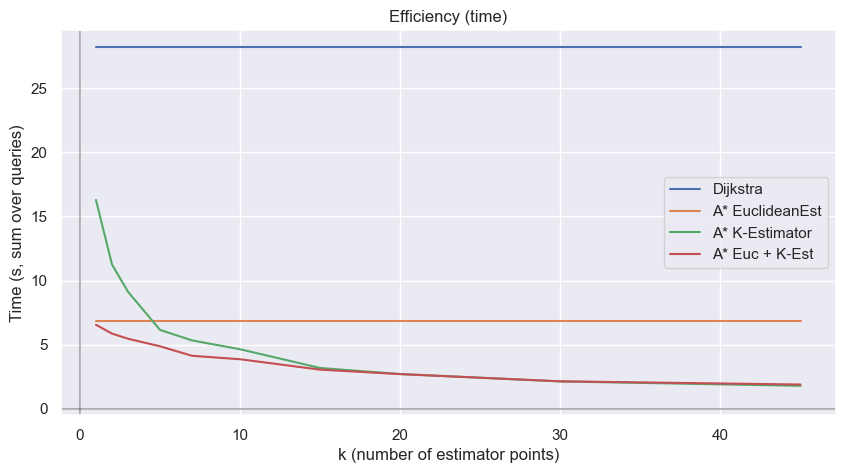

In [419]:
plt.figure(figsize=(10, 5))

plot_times(k_array, dij_stat_array, "Dijkstra")
plot_times(k_array, euc_stat_array, "A* EuclideanEst")
plot_times(k_array, k_est_stat_array, "A* K-Estimator")
plot_times(k_array, comb_stat_array, "A* Euc + K-Est")

plt.title("Efficiency (time)")
plt.xlabel("k (number of estimator points)")
plt.ylabel("Time (s, sum over queries)")

# plt.grid()

plt.ylim(-0.5)

plt.axhline(y=0, color='k', alpha=0.3)
plt.axvline(x=0, color='k', alpha=0.3)

_ = plt.legend()

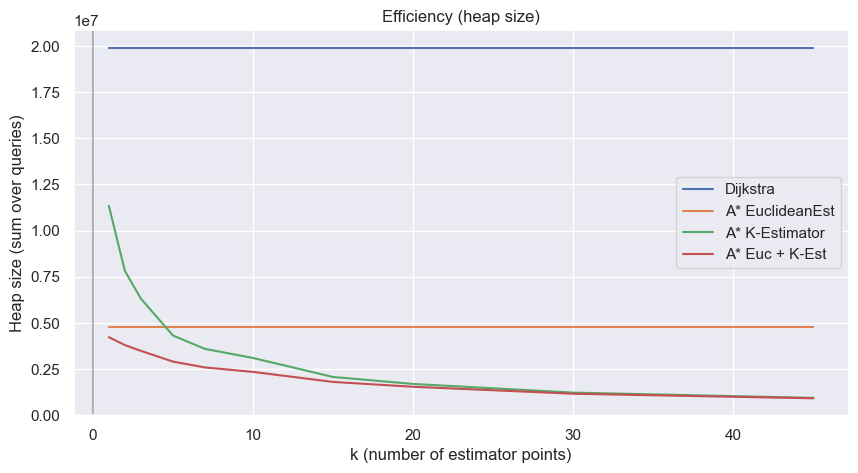

In [422]:
plt.figure(figsize=(10, 5))

plot_heap(k_array, dij_stat_array, "Dijkstra")
plot_heap(k_array, euc_stat_array, "A* EuclideanEst")
plot_heap(k_array, k_est_stat_array, "A* K-Estimator")
plot_heap(k_array, comb_stat_array, "A* Euc + K-Est")

plt.title("Efficiency (heap size)")
plt.xlabel("k (number of estimator points)")
plt.ylabel("Heap size (sum over queries)")

plt.ylim(0)

plt.axhline(y=0, color='k', alpha=0.3)
plt.axvline(x=0, color='k', alpha=0.3)

_ = plt.legend()